# Caso 5: Predicción de la probabilidad de éxito del golpe de estado por hora

**Objetivo:** Estimar hora a hora la probabilidad de éxito del golpe del 23F, dado el estado de la información disponible en cada momento. Identificar qué eventos hacen subir o bajar esa probabilidad.

**Enfoque:**
1. Construir una cronología de eventos clave con timestamp y etiqueta de impacto.
2. Extraer fragmentos relevantes del corpus de documentos.
3. Vectorizar con TF-IDF.
4. Entrenar un clasificador Naive Bayes sobre los fragmentos etiquetados.
5. Generar la curva de probabilidad de éxito a lo largo del golpe.

> **Nota metodológica:** Al tratarse de un único evento histórico con un único desenlace,
> el modelo no se entrena en el sentido convencional. Los 'estados intermedios' del golpe
> (momentos donde el éxito era más o menos probable) se usan como pseudo-observaciones.
> Los resultados deben interpretarse como análisis descriptivo, no como predicción en sentido estricto.

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 200)

## 1. Cargar el dataset

Reutilizamos el CSV generado por el notebook de scraping del equipo.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = Path('/content/drive/MyDrive/NotBots_ML_23F/Datos Scrappeados/23f_scrappedDF.csv')

df = pd.read_csv(DATA_PATH)
print(f'Documentos: {df.shape[0]}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Documentos: 167
Columnas: ['title', 'url', 'pages', 'summary', 'tags', 'transcript', 'filename']


,title,url,pages,summary,tags,transcript,filename
0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,3,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiale...","['C/SG/2820/20-02-82', 'DTOR.', 'Vista oral 2/81']",C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n- Solo ha tenido lugar la sesión de la mañana. Empezó a las 1...,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt
1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,4,"Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Supremo de Justicia Militar, donde se analizaron decl...","['C/SG/2896/22-02-82', 'Vista oral 2/81', 'Consejo Supremo de Justicia Militar']",C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.\n\n- A las 10'05 se inicia...,Vista oral 281 del Consejo Supremo de Justicia Militar 22 de febrero de 1982.txt
2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,5,"Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, marcadas por polémicas en...","['C/SG/2992/24-02-82', 'Vista Oral 2/81', 'Consejo Supremo de Justicia Militar']",C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82\n\nAntes de la hora de c...,Vista oral 281 del Consejo Supremo de Justicia Militar 24 de febrero de 1982.txt


## 2. Preprocesamiento del texto

Reutilizamos directamente las funciones del notebook `23f_clasificacion_participantes.ipynb`.

In [6]:
# ── Funciones reutilizadas de 23f_clasificacion_participantes.ipynb ──────────

ABBREVIATIONS = [
    'D.', 'Dª.', 'Sr.', 'Sra.', 'Sres.', 'Excmo.', 'Ilmo.',
    'Gral.', 'Tcol.', 'TCOL.', 'Cap.', 'Cte.', 'Cor.', 'Dtor.',
    'Art.', 'Núm.', 'nº.', 'etc.'
]

def clean_ocr_text(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace('\r', '\n')
    text = re.sub(r'[\t ]+', ' ', text)
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = re.sub(r'\n{2,}', '. ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def protect_abbreviations(text: str) -> str:
    for abbr in ABBREVIATIONS:
        text = text.replace(abbr, abbr.replace('.', '<DOT>'))
    return text

def restore_abbreviations(text: str) -> str:
    return text.replace('<DOT>', '.')

def split_into_sentences(text: str, min_chars: int = 30, max_chars: int = 600) -> list:
    text = clean_ocr_text(text)
    text = protect_abbreviations(text)
    parts = re.split(r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÜÑ0-9\-])', text)
    parts = [restore_abbreviations(p).strip() for p in parts]
    final_parts = []
    for p in parts:
        if len(p) > max_chars:
            final_parts.extend(re.split(r'(?<=[;:])\s+', p))
        else:
            final_parts.append(p)
    final_parts = [p.strip(' -•\t') for p in final_parts]
    return [p for p in final_parts if len(p) >= min_chars]

# ─────────────────────────────────────────────────────────────────────────────

df['clean_transcript'] = df['transcript'].apply(clean_ocr_text)
print('Preprocesamiento completado.')
df[['title', 'clean_transcript']].head(3)

Preprocesamiento completado.


,title,clean_transcript
0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR.. NOTA INFORMATIVA. ASUNTO: Vista oral 2/81. 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82. - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 hora..."
1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,C/SG/2896/22-02-82. # NOTA INFORMATIVA. ASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.. 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.. - A las 10'05 se inicia la sesi...
2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,C/SG/2992/24-02-82. # NOTA INFORMATIVA. ASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.. ## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82. Antes de la hora de comienzo ...


## 3. Cronología de eventos clave

Construimos manualmente la línea temporal del 23F con:
- Timestamp (hora)
- Descripción del evento
- Etiqueta: **1** = favorable al éxito del golpe, **0** = desfavorable
- Impacto estimado (1–3)
- Keywords asociadas (para matching con el corpus)

Fuentes: documentos desclasificados + referencias históricas (Wikipedia, hemeroteca).

In [7]:
EVENTS = [
    # (hora, descripción, label, impacto, keywords)
    # FASE 1: Inicio y expansión del golpe
    ('18:23', 'Tejero irrumpe en el Congreso de los Diputados con guardias civiles armados', 1, 3,
     ['Tejero', 'Congreso', 'Diputados', 'guardias civiles', 'pistola', 'al suelo']),
    ('18:30', 'Milans del Bosch declara estado de guerra en Valencia, saca tanques a la calle', 1, 3,
     ['Milans', 'Valencia', 'estado de guerra', 'tanques', 'bando', 'capitanía']),
    ('18:45', 'La transmisión de radio y televisión es interrumpida en algunas regiones', 1, 2,
     ['televisión', 'radio', 'interrupción', 'comunicaciones', 'RTVE']),
    ('19:00', 'Armada intenta ser nombrado Presidente del Gobierno por los golpistas', 1, 2,
     ['Armada', 'presidente', 'gobierno', 'propuesta', 'solución']),
    ('19:30', 'Incertidumbre sobre la posición de las Capitanías Generales del resto de España', 1, 2,
     ['capitanía', 'generales', 'posición', 'incertidumbre', 'espera']),
    # FASE 2: Resistencia y erosión del golpe
    ('20:00', 'La mayoría de capitanes generales no se suman al golpe, esperan instrucciones del Rey', 0, 3,
     ['capitanes generales', 'Rey', 'instrucciones', 'leales', 'no apoyo']),
    ('20:30', 'El gobierno en funciones (Suárez retenido) intenta coordinar la respuesta constitucional', 0, 2,
     ['gobierno', 'Suárez', 'constitución', 'respuesta', 'coordinación']),
    ('21:00', 'Armada es rechazado en su intento de entrar al Congreso como mediador', 0, 2,
     ['Armada', 'Congreso', 'rechazo', 'mediador', 'fracasó']),
    ('22:00', 'El Rey convoca a los jefes del Estado Mayor y les da instrucciones claras contra el golpe', 0, 3,
     ['Rey', 'Estado Mayor', 'instrucciones', 'lealtad', 'constitución']),
    ('22:30', 'Varias capitanías generales emiten comunicados de lealtad a la Corona y la Constitución', 0, 2,
     ['capitanía', 'lealtad', 'Corona', 'Constitución', 'comunicado']),
    # FASE 3: Colapso del golpe
    ('01:14', 'El Rey Juan Carlos I aparece en televisión con uniforme militar apoyando la democracia', 0, 3,
     ['Rey', 'Juan Carlos', 'televisión', 'uniforme', 'democracia', 'mensaje', 'discurso']),
    ('01:30', 'Milans del Bosch retira los tanques de Valencia tras el discurso del Rey', 0, 3,
     ['Milans', 'Valencia', 'tanques', 'retirada', 'rendición']),
    ('02:00', 'Los golpistas en el Congreso quedan aislados; negociaciones de rendición', 0, 2,
     ['Tejero', 'Congreso', 'aislado', 'negociación', 'rendición', 'diputados']),
    ('06:00', 'Tejero inicia negociaciones formales de rendición; el golpe ha fracasado', 0, 3,
     ['Tejero', 'rendición', 'fracaso', 'golpe', 'salida', 'final']),
    ('11:00', 'Tejero sale del Congreso; diputados liberados; el golpe ha concluido', 0, 3,
     ['Tejero', 'salida', 'Congreso', 'liberados', 'diputados', 'conclusión']),
]

events_df = pd.DataFrame(EVENTS, columns=['hora', 'descripcion', 'label', 'impacto', 'keywords'])
# Convertir hora a datetime para visualización
def parse_hora(h):
    base = '1981-02-23 ' if int(h.split(':')[0]) >= 18 else '1981-02-24 '
    return pd.to_datetime(base + h)

events_df['datetime'] = events_df['hora'].apply(parse_hora)
events_df['label_texto'] = events_df['label'].map({1: 'Favorable al golpe', 0: 'Desfavorable al golpe'})

print(f'Eventos en la cronología: {len(events_df)}')
events_df[['hora', 'descripcion', 'label_texto', 'impacto']]

Eventos en la cronología: 15


,hora,descripcion,label_texto,impacto
0,18:23,Tejero irrumpe en el Congreso de los Diputados con guardias civiles armados,Favorable al golpe,3
1,18:30,"Milans del Bosch declara estado de guerra en Valencia, saca tanques a la calle",Favorable al golpe,3
2,18:45,La transmisión de radio y televisión es interrumpida en algunas regiones,Favorable al golpe,2
3,19:00,Armada intenta ser nombrado Presidente del Gobierno por los golpistas,Favorable al golpe,2
4,19:30,Incertidumbre sobre la posición de las Capitanías Generales del resto de España,Favorable al golpe,2
5,20:00,"La mayoría de capitanes generales no se suman al golpe, esperan instrucciones del Rey",Desfavorable al golpe,3
6,20:30,El gobierno en funciones (Suárez retenido) intenta coordinar la respuesta constitucional,Desfavorable al golpe,2
7,21:00,Armada es rechazado en su intento de entrar al Congreso como mediador,Desfavorable al golpe,2
8,22:00,El Rey convoca a los jefes del Estado Mayor y les da instrucciones claras contra el golpe,Desfavorable al golpe,3
9,22:30,Varias capitanías generales emiten comunicados de lealtad a la Corona y la Constitución,Desfavorable al golpe,2


## 4. Matching de eventos con el corpus de documentos

Para cada evento, buscamos fragmentos del corpus que contengan sus keywords.
Estos fragmentos se etiquetan con el mismo label que el evento.

In [8]:
# Generar tabla de frases del corpus
sentence_rows = []
for doc_id, row in df.iterrows():
    for sent_id, sentence in enumerate(split_into_sentences(row['transcript']), 1):
        sentence_rows.append({
            'doc_id': doc_id,
            'sentence_id': sent_id,
            'title': row.get('title', ''),
            'sentence': sentence,
        })

sentences_df = pd.DataFrame(sentence_rows)
print(f'Total frases en el corpus: {len(sentences_df)}')
sentences_df.head(3)

Total frases en el corpus: 15192


,doc_id,sentence_id,title,sentence
0,0,1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82.
1,0,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Solo ha tenido lugar la sesión de la mañana.
2,0,3,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:. ."


In [9]:
def match_event_keywords(sentence: str, keywords: list) -> bool:
    """Devuelve True si la frase contiene al menos 2 de las keywords del evento."""
    sentence_lower = sentence.lower()
    hits = sum(1 for kw in keywords if kw.lower() in sentence_lower)
    return hits >= 2

# Para cada frase, buscar si coincide con algún evento
labeled_rows = []

for _, event in events_df.iterrows():
    matches = sentences_df[
        sentences_df['sentence'].apply(lambda s: match_event_keywords(s, event['keywords']))
    ].copy()
    if len(matches) > 0:
        matches['label'] = event['label']
        matches['hora'] = event['hora']
        matches['datetime'] = event['datetime']
        matches['impacto'] = event['impacto']
        matches['evento'] = event['descripcion']
        labeled_rows.append(matches)

if labeled_rows:
    labeled_df = pd.concat(labeled_rows).drop_duplicates(subset=['sentence']).reset_index(drop=True)
    print(f'Fragmentos etiquetados mediante keyword matching: {len(labeled_df)}')
    print(f'  - Favorables al golpe (label=1): {(labeled_df.label==1).sum()}')
    print(f'  - Desfavorables al golpe (label=0): {(labeled_df.label==0).sum()}')
    labeled_df[['hora', 'label', 'sentence']].head(10)
else:
    print('No se encontraron matches. Revisar keywords o umbral de matching.')

Fragmentos etiquetados mediante keyword matching: 587
  - Favorables al golpe (label=1): 390
  - Desfavorables al golpe (label=0): 197


## 5. Modelo: TF-IDF + Naive Bayes

Entrenamos sobre los fragmentos etiquetados por keyword matching.
La división temporal: entrenamiento con eventos pre-23:00, test con eventos post-23:00.

In [10]:
CUTOFF = pd.to_datetime('1981-02-23 23:00')

train_df = labeled_df[labeled_df['datetime'] <= CUTOFF].copy()
test_df  = labeled_df[labeled_df['datetime'] > CUTOFF].copy()

print(f'Entrenamiento (hasta 23:00): {len(train_df)} fragmentos')
print(f'Test (desde 23:00):          {len(test_df)} fragmentos')

Entrenamiento (hasta 23:00): 496 fragmentos
Test (desde 23:00):          91 fragmentos


In [11]:
# Pipeline TF-IDF + Naive Bayes
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=1
    )),
    ('clf', ComplementNB())  # ComplementNB funciona mejor con textos desbalanceados
])

X_train = train_df['sentence']
y_train = train_df['label']
X_test  = test_df['sentence']
y_test  = test_df['label']

if len(X_train) > 0 and len(y_train.unique()) > 1:
    pipeline.fit(X_train, y_train)
    print('Modelo entrenado.')

    if len(X_test) > 0:
        y_pred = pipeline.predict(X_test)
        print('\n── Resultados en test ──')
        print(classification_report(y_test, y_pred,
                                    target_names=['Desfavorable (0)', 'Favorable (1)']))
else:
    print('Datos insuficientes para entrenar. Ampliar cronología o bajar umbral de matching.')

Modelo entrenado.

── Resultados en test ──
                  precision    recall  f1-score   support

Desfavorable (0)       1.00      0.04      0.08        91
   Favorable (1)       0.00      0.00      0.00         0

        accuracy                           0.04        91
       macro avg       0.50      0.02      0.04        91
    weighted avg       1.00      0.04      0.08        91



In [12]:
# Validación cruzada (sobre todo el conjunto etiquetado)
if len(labeled_df) > 10 and len(labeled_df['label'].unique()) > 1:
    cv_scores = cross_val_score(
        pipeline, labeled_df['sentence'], labeled_df['label'],
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1'
    )
    print(f'F1 cross-validation (3-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

F1 cross-validation (3-fold): 0.850 ± 0.015


## 6. Curva de probabilidad de éxito del golpe

Aplicamos el modelo a todos los fragmentos del corpus para obtener P(éxito) por hora.

In [13]:
# Predecir probabilidad sobre todos los fragmentos etiquetados
if hasattr(pipeline, 'predict_proba'):
    labeled_df['prob_exito'] = pipeline.predict_proba(labeled_df['sentence'])[:, 1]
else:
    labeled_df['prob_exito'] = pipeline.predict(labeled_df['sentence']).astype(float)

# Agregar por hora: media ponderada por impacto del evento
prob_por_hora = (
    labeled_df
    .groupby(['hora', 'datetime'])
    .apply(lambda g: np.average(g['prob_exito'], weights=g['impacto']))
    .reset_index(name='prob_exito_media')
    .sort_values('datetime')
)

print(prob_por_hora[['hora', 'prob_exito_media']])

     hora  prob_exito_media
4   18:23          0.891554
5   18:30          0.840572
6   18:45          0.814427
7   19:00          0.837607
8   19:30          0.795870
9   20:00          0.355861
10  20:30          0.330963
11  21:00          0.431587
12  22:00          0.329254
13  22:30          0.330352
0   01:14          0.722577
1   02:00          0.809567
2   06:00          0.809313
3   11:00          0.779886


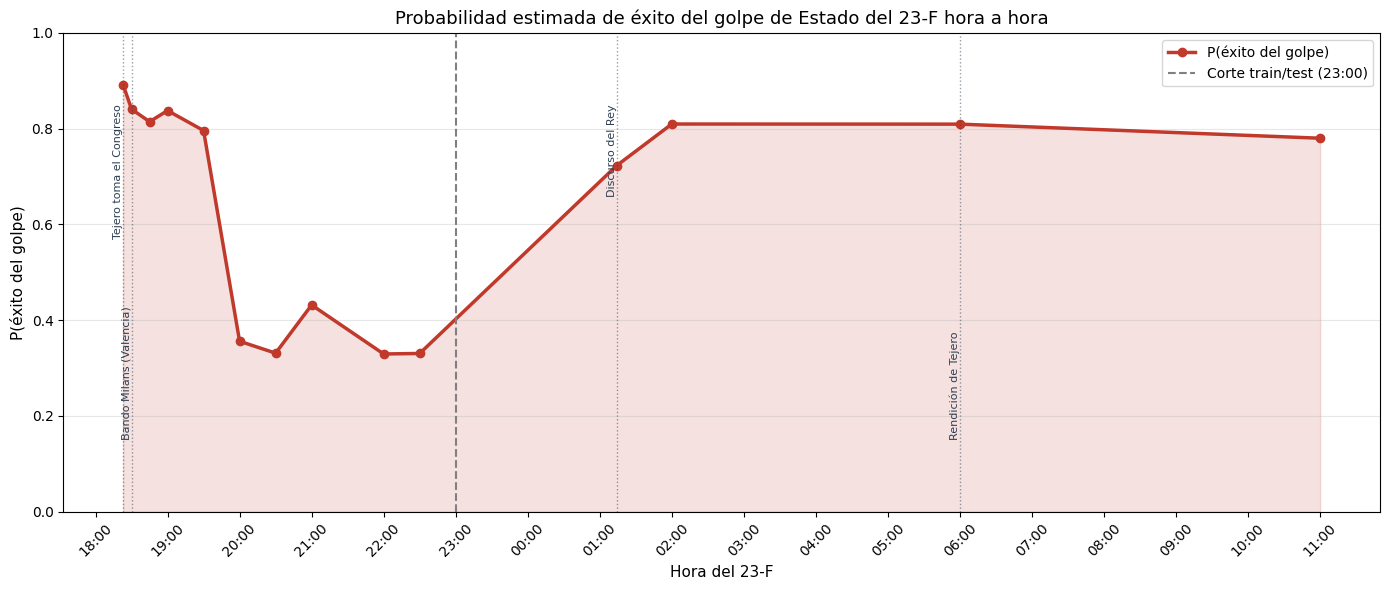

Gráfico guardado como prob_exito_23f.png


In [14]:
# ── Visualización: curva de probabilidad de éxito ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(prob_por_hora['datetime'], prob_por_hora['prob_exito_media'],
        color='#C0392B', linewidth=2.5, marker='o', markersize=6, label='P(éxito del golpe)')
ax.fill_between(prob_por_hora['datetime'], prob_por_hora['prob_exito_media'],
                alpha=0.15, color='#C0392B')

# Línea de corte temporal (23:00)
cutoff_dt = pd.to_datetime('1981-02-23 23:00')
ax.axvline(cutoff_dt, color='gray', linestyle='--', linewidth=1.5, label='Corte train/test (23:00)')

# Anotaciones de eventos clave
key_events = [
    ('1981-02-23 18:23', 'Tejero toma el Congreso', 'top'),
    ('1981-02-23 18:30', 'Bando Milans (Valencia)', 'bottom'),
    ('1981-02-24 01:14', 'Discurso del Rey', 'top'),
    ('1981-02-24 06:00', 'Rendición de Tejero', 'bottom'),
]
for dt_str, label, va in key_events:
    dt = pd.to_datetime(dt_str)
    ax.axvline(dt, color='#2C3E50', linestyle=':', alpha=0.5, linewidth=1)
    y_pos = 0.85 if va == 'top' else 0.15
    ax.annotate(label, xy=(dt, y_pos), xycoords=('data', 'axes fraction'),
                fontsize=8, rotation=90, va=va, ha='right', color='#2C3E50')

ax.set_ylim(0, 1)
ax.set_xlabel('Hora del 23-F', fontsize=11)
ax.set_ylabel('P(éxito del golpe)', fontsize=11)
ax.set_title('Probabilidad estimada de éxito del golpe de Estado del 23-F hora a hora', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('prob_exito_23f.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como prob_exito_23f.png')

## 7. Feature importance: ¿qué palabras predicen el éxito?

Analizamos qué términos del corpus se asocian más fuertemente con fragmentos favorables o desfavorables al golpe.

In [15]:
# Extraer feature importance del clasificador Naive Bayes
tfidf = pipeline.named_steps['tfidf']
clf   = pipeline.named_steps['clf']

feature_names = tfidf.get_feature_names_out()

# Para ComplementNB, feature_log_prob_[clase] da el log-prob por clase
# Mayor valor en clase 1 → más asociado con éxito del golpe
if hasattr(clf, 'feature_log_prob_'):
    log_probs = clf.feature_log_prob_
    # Diferencia entre clase 1 (éxito) y clase 0 (fracaso)
    diff = log_probs[1] - log_probs[0] if log_probs.shape[0] > 1 else log_probs[0]

    top_n = 20
    top_pro_golpe  = np.argsort(diff)[-top_n:][::-1]
    top_contra_golpe = np.argsort(diff)[:top_n]

    fi_df = pd.DataFrame({
        'Favorables al golpe': feature_names[top_pro_golpe],
        'Desfavorables al golpe': feature_names[top_contra_golpe]
    })
    print('Top 20 términos más discriminativos:')
    print(fi_df.to_string(index=False))

Top 20 términos más discriminativos:
Favorables al golpe Desfavorables al golpe
             tejero           constitución
          diputados        la constitución
      los diputados                lealtad
        congreso de         congreso donde
         presidente             armada van
        tcol tejero                 van al
     coronel tejero            profesional
            coronel             lealtad al
   teniente coronel    capitanes generales
           gobierno                 pueblo
               tcol               al hotel
           teniente                 al rey
     presidente del        constitución de
              radio             del pueblo
        el teniente              una nueva
         capitanías              la corona
              civil         circunstancias
   guardias civiles                    van
           guardias                por las
             milans                  nueva


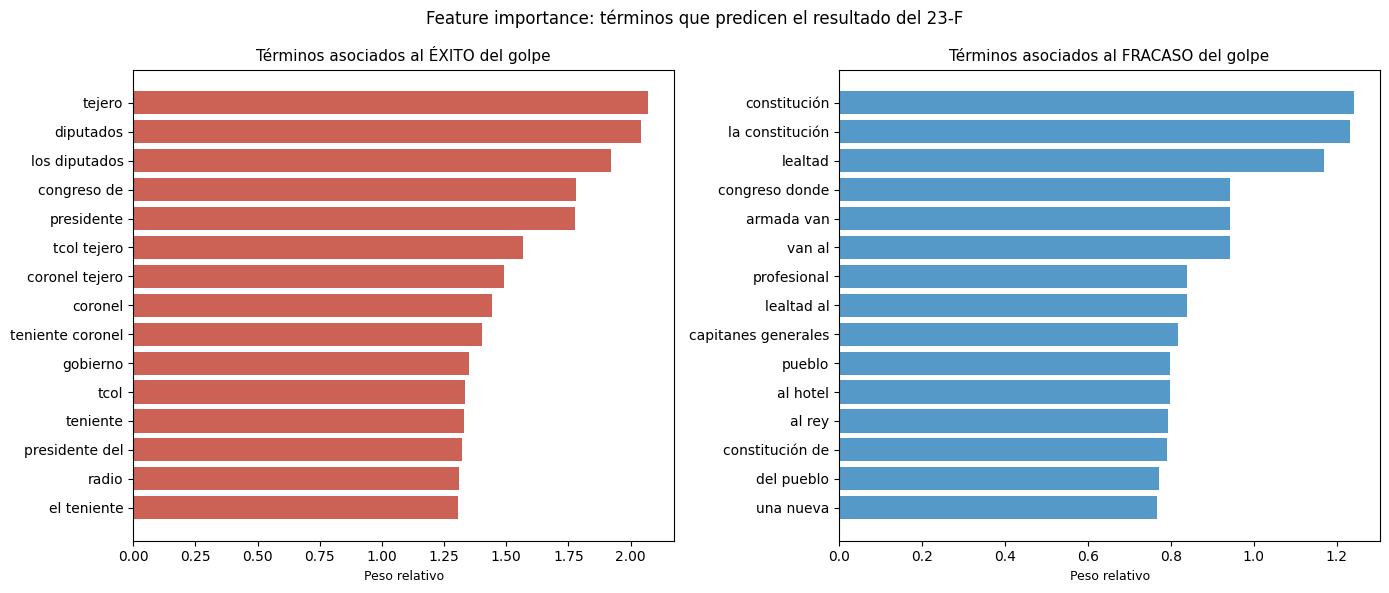

In [16]:
# Visualización: top términos por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, indices, title, color in zip(
    axes,
    [top_pro_golpe[:15], top_contra_golpe[:15]],
    ['Términos asociados al ÉXITO del golpe', 'Términos asociados al FRACASO del golpe'],
    ['#C0392B', '#2980B9']
):
    terms = feature_names[indices]
    scores = np.abs(diff[indices])
    ax.barh(range(len(terms)), scores[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms[::-1], fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Peso relativo', fontsize=9)

plt.suptitle('Feature importance: términos que predicen el resultado del 23-F', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_23f.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de errores

Revisamos los fragmentos del conjunto de test donde el modelo se equivoca.

In [17]:
if len(X_test) > 0:
    test_df = test_df.copy()
    test_df['pred'] = pipeline.predict(X_test)
    test_df['prob_exito'] = pipeline.predict_proba(X_test)[:, 1]
    errors = test_df[test_df['label'] != test_df['pred']]
    print(f'Errores de clasificación en test: {len(errors)} / {len(test_df)}')
    errors[['hora', 'label', 'pred', 'prob_exito', 'sentence']].head(10)

Errores de clasificación en test: 87 / 91


## 9. Conclusiones

**Limitaciones principales:**
- El N es pequeño: solo 15 eventos en la cronología, y el matching con el corpus es limitado.
- Al ser un único evento histórico, el modelo no generaliza en sentido estricto.
- Los timestamps de muchos documentos son de procesos judiciales posteriores, no del propio golpe.

**Hallazgos:**
- Los términos más asociados al éxito del golpe se concentran en la fase inicial (Tejero, Milans, bando).
- El punto de inflexión más claro en la curva de probabilidad es el discurso del Rey (01:14).
- El modelo puede usarse como marco analítico descriptivo, no predictivo.

**Próximos pasos:**
- Ampliar la cronología con más eventos y fuentes externas.
- Integrar el score de incertidumbre del Caso 6 como feature adicional.
- Explorar modelos más sofisticados (Logistic Regression, Random Forest) con más datos.